# Implementación de Regresión Logística desde Cero
**Objetivo:** Desarrollar un modelo de Regresión Logística utilizando únicamente `NumPy` para entender la matemática subyacente (Máxima Verosimilitud y Descenso de Gradiente).

## 1. Fundamentos Teóricos

**¿Por qué no funciona para clasificación binaria?**

- Queremos predecir probabilidades: $P(y=1|x) \in [0,1]$
- Regresión lineal puede dar valores fuera de $[0,1]$ (ej: $-2.5$ o $3.8$)
- No tiene interpretación probabilística natural

#### La solución: transformar la salida lineal

Necesitamos una función que:

1. Tome cualquier valor real (la salida lineal)
2. Lo comprima al rango $[0,1]$ (probabilidad válida)
3. Sea diferenciable (para optimización)

---

### 1.2 La Función Sigmoide

**Definición:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

donde $z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$ es nuestra combinación lineal.

**Propiedades clave:**

- Cuando $z \to +\infty$: $\sigma(z) \to 1$
- Cuando $z \to -\infty$: $\sigma(z) \to 0$
- Cuando $z = 0$: $\sigma(z) = 0.5$
- Es diferenciable: $\sigma'(z) = \sigma(z)(1-\sigma(z))$

**Interpretación:**
$$P(y=1|\mathbf{x}) = \sigma(\mathbf{x}^T\boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}^T\boldsymbol{\beta}}}$$

---


### 1.3 ¿Por qué esta fórmula? El Modelo Logit

La regresión logística asume que el **log-odds** (logaritmo de las probabilidades relativas) es lineal:

$$\log\left(\frac{P(y=1|\mathbf{x})}{P(y=0|\mathbf{x})}\right) = \mathbf{x}^T\boldsymbol{\beta}$$

**Derivación:**

Si llamamos $p = P(y=1|\mathbf{x})$, entonces:

$$\log\left(\frac{p}{1-p}\right) = \mathbf{x}^T\boldsymbol{\beta}$$

Aplicando exponencial a ambos lados:

$$\frac{p}{1-p} = e^{\mathbf{x}^T\boldsymbol{\beta}}$$

Resolviendo para $p$:

$$p = (1-p) \cdot e^{\mathbf{x}^T\boldsymbol{\beta}}$$
$$p = e^{\mathbf{x}^T\boldsymbol{\beta}} - p \cdot e^{\mathbf{x}^T\boldsymbol{\beta}}$$
$$p(1 + e^{\mathbf{x}^T\boldsymbol{\beta}}) = e^{\mathbf{x}^T\boldsymbol{\beta}}$$

$$\boxed{p = \frac{e^{\mathbf{x}^T\boldsymbol{\beta}}}{1 + e^{\mathbf{x}^T\boldsymbol{\beta}}} = \frac{1}{1 + e^{-\mathbf{x}^T\boldsymbol{\beta}}}}$$

Esta es exactamente la función sigmoide.

## 2 Estimación de Parámetros: Máxima Verosimilitud

### 2.1 La función de verosimilitud

A diferencia de regresión lineal (que usa mínimos cuadrados), la regresión logística se estima mediante **Máxima Verosimilitud**.

**¿Por qué?** Porque estamos modelando probabilidades, no valores continuos.

Para una observación $(x_i, y_i)$ donde $y_i \in \{0,1\}$:

$$P(y_i | \mathbf{x}_i) = \begin{cases}
p_i & \text{si } y_i = 1 \\
1-p_i & \text{si } y_i = 0
\end{cases}$$

Esto se puede escribir de forma compacta:

$$P(y_i | \mathbf{x}_i) = p_i^{y_i} \cdot (1-p_i)^{1-y_i}$$

donde $p_i = \sigma(\mathbf{x}_i^T\boldsymbol{\beta})$

### 2.2 De verosimilitud a log-verosimilitud

Para $n$ observaciones independientes, la verosimilitud conjunta es:

$$\mathcal{L}(\boldsymbol{\beta}) = \prod_{i=1}^{n} p_i^{y_i} \cdot (1-p_i)^{1-y_i}$$

Tomamos logaritmo (más fácil de optimizar, productos → sumas):

$$\ell(\boldsymbol{\beta}) = \log \mathcal{L}(\boldsymbol{\beta}) = \sum_{i=1}^{n} \Big[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \Big]$$

### 2.3 Función de Coste (Log-Loss)

En machine learning, **minimizamos** en lugar de maximizar, así que:

$$\boxed{J(\boldsymbol{\beta}) = -\frac{1}{n} \sum_{i=1}^{n} \Big[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \Big]}$$

Esta es la **entropía cruzada binaria** (binary cross-entropy).


## 3. Desarrollo Matemático: ¿De dónde sale el Gradiente?

Para aplicar el Descenso de Gradiente, necesitamos saber cómo cambia el error ($J$) si movemos un poco un peso ($\beta_j$). Matemáticamente, buscamos la derivada parcial:
$$\frac{\partial J}{\partial \beta_j}$$

Utilizamos la **Regla de la Cadena**, descomponiendo la derivada en 3 partes:

1. Cómo cambia el **Coste** ($J$) respecto a la **Predicción** ($p$).
2. Cómo cambia la **Predicción** ($p$) respecto a la **Salida Lineal** ($z$).
3. Cómo cambia la **Salida Lineal** ($z$) respecto al **Peso** ($\beta_j$).

$$\frac{\partial J}{\partial \beta_j} = \underbrace{\frac{\partial J}{\partial p}}_{A} \cdot \underbrace{\frac{\partial p}{\partial z}}_{B} \cdot \underbrace{\frac{\partial z}{\partial \beta_j}}_{C}$$

---

### Paso A: Derivada del Coste respecto a la Predicción
La función de coste para una sola muestra es:
$$J = - [y \ln(p) + (1-y) \ln(1-p)]$$

Derivamos respecto a $p$:
$$\frac{\partial J}{\partial p} = - \left( \frac{y}{p} - \frac{1-y}{1-p} \right) = \frac{p - y}{p(1-p)}$$

### Paso B: Derivada de la Sigmoide
Nuestra predicción es $p = \sigma(z) = \frac{1}{1+e^{-z}}$.

La sigmoide tiene una propiedad especial: su derivada se expresa en términos de sí misma.
$$\frac{\partial p}{\partial z} = p \cdot (1 - p)$$

**Demostración:**
$$\frac{d}{dz}\left(\frac{1}{1+e^{-z}}\right) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z) \cdot (1-\sigma(z))$$

### Paso C: Derivada de la Ecuación Lineal
Definimos $z = \beta_0 + \beta_1 x_1 + \dots + \beta_j x_j$.

Si derivamos respecto a $\beta_j$, solo sobrevive el término $x_j$:
$$\frac{\partial z}{\partial \beta_j} = x_j$$

---

### 🏁 Paso Final: Uniendo todo (La Cancelación)
Multiplicamos las tres partes ($A \cdot B \cdot C$):

$$\frac{\partial J}{\partial \beta_j} = \left( \frac{p - y}{p(1-p)} \right) \cdot \big( p(1-p) \big) \cdot x_j$$

Observa cómo el denominador del paso A se cancela perfectamente con el resultado del paso B:

$$\frac{\partial J}{\partial \beta_j} = \frac{p - y}{\cancel{p(1-p)}} \cdot \cancel{p(1-p)} \cdot x_j$$

$$\boxed{\frac{\partial J}{\partial \beta_j} = (p - y) \cdot x_j}$$

**Conclusión:**
Esta simplicidad es lo que hace que la Regresión Logística sea tan eficiente computacionalmente. El gradiente es simplemente el **error de predicción** multiplicado por el **valor de la entrada**.

---

### 3.1 Fórmula Vectorial del Gradiente

Para $n$ observaciones, promediamos sobre todas:

$$\frac{\partial J}{\partial \beta_j} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i) x_{ij}$$

**En forma vectorial:**
$$\nabla J(\boldsymbol{\beta}) = \frac{1}{n} \mathbf{X}^T (\mathbf{p} - \mathbf{y})$$

Esta es la expresión que usaremos en el código.

---

## 4. Vectorización para Implementación Eficiente

Para una implementación eficiente en Python, evitamos los bucles `for` y usamos álgebra lineal.

**Dimensiones:**
- $X$: Matriz de datos $(n, \text{features})$
- $y$: Vector de etiquetas $(n, 1)$
- $w$: Vector de pesos (coeficientes) $(\text{features}, 1)$
- $b$: Escalar (bias/intercepto)

**Fórmulas Vectorizadas:**

1. **Modelo:**
   $$\hat{y} = \sigma(X \cdot w + b)$$

2. **Gradiente de w:**
   $$\nabla_w = \frac{1}{n} X^T (\hat{y} - y)$$

3. **Gradiente de b:**
   $$\nabla_b = \frac{1}{n} \sum (\hat{y} - y)$$

4. **Actualización (Descenso de Gradiente):**
   $$w = w - \alpha \cdot \nabla_w$$
   $$b = b - \alpha \cdot \nabla_b$$

   *(Donde $\alpha$ es la tasa de aprendizaje o learning rate)*

---

## 5. Algoritmo Completo de Descenso de Gradiente

**Pseudocódigo:**

```
1. Inicializar w = 0, b = 0
2. Para cada iteración t = 1, 2, ..., T:
   a. Calcular predicciones: ŷ = σ(X·w + b)
   b. Calcular error: e = ŷ - y
   c. Calcular gradientes:
      ∇w = (1/n) · X^T · e
      ∇b = (1/n) · sum(e)
   d. Actualizar parámetros:
      w = w - α · ∇w
      b = b - α · ∇b
   e. (Opcional) Calcular y guardar el coste J
3. Retornar w, b
```

In [ ]:
import numpy as np

class RegresionLogisticaDesdeCero:
    """
    Implementación de Regresión Logística desde cero usando NumPy.

    Parámetros:
    -----------
    learning_rate : float
        Tasa de aprendizaje para el descenso de gradiente (α)
    n_iterations : int
        Número de iteraciones para el entrenamiento
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []  # Para guardar el historial de pérdidas

    def _sigmoid(self, z):
        """Función sigmoide: σ(z) = 1 / (1 + e^(-z))"""
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred):
        """Calcula la función de coste (Binary Cross-Entropy)"""
        epsilon = 1e-15  # Para evitar log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        print(f"y_true: {y_true.flatten()}")
        print(f"y_pred: {y_pred.flatten()}")
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        print(f"Pérdida calculada: {loss}")
        return loss

    def fit(self, X, y):
        """
        Entrena el modelo usando descenso de gradiente.

        Parámetros:
        -----------
        X : array-like, shape (n_samples, n_features)
            Datos de entrenamiento
        y : array-like, shape (n_samples,)
            Etiquetas objetivo (0 o 1)
        """
        n_samples, n_features = X.shape

        # Inicializar parámetros
        # self.weights = np.zeros((n_features, 1))
        # self.bias = 0
        self.weights = np.random.rand(n_features, 1) * 0.01  # Pequeños valores aleatorios
        self.bias = 0
        
        # Asegurar que y tenga la forma correcta
        y = y.reshape(-1, 1)

        # Descenso de gradiente
        for i in range(self.n_iters):
            # 1. Calcular predicciones: ŷ = σ(X·w + b)
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)

            # 2. Calcular gradientes
            error = y_pred - y
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            # 3. Actualizar parámetros
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # 4. Guardar pérdida cada 100 iteraciones
            if i % 10 == 0:
                loss = self._compute_loss(y, y_pred)
                self.losses.append(loss)
                if i % 50 == 0:
                    print(f"Iteración {i}: Loss = {loss:.4f}")

    def predict_proba(self, X):
        """Predice probabilidades P(y=1|X)"""
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Predice clases (0 o 1) usando un umbral"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [35]:
# Ejemplo de uso:

# Lecture data python from titanic

import pandas as pd
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import StandardScaler
data = pd.read_csv('train_and_test2.csv')

# Preprocesamiento simple
# Quitar columna ID
# Ejemplo de uso:

# Lecture data python from titanic
import pandas as pd
data = pd.read_csv('train_and_test2.csv')
scaler = StandardScaler()


# Preprocesamiento simple
# Quitar columna ID
data = data.drop(columns=['Passengerid'], axis=1)  # axis=1 para columnas # axis = 1 para columnas y 0 para filas
data.dropna(inplace=True)
y = data['2urvived'].values
X = data.drop(columns=['2urvived']).values
X = scaler.fit_transform(X)
# Los ya están preprocesados
# Dividir en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Entrenar el modelo
model = RegresionLogisticaDesdeCero(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)
# Hacer predicciones
y_pred = model.predict(X_test)
# Evaluar el modelo
# Hacer predicciones
# Evaluar el modelo
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


y_true: [0 0 1 ... 0 1 0]
y_pred: [0.49491413 0.49874718 0.49846332 ... 0.49407903 0.50084865 0.49558735]
Pérdida calculada: 0.6930501440553056
Iteración 0: Loss = 0.6931
y_true: [0 0 1 ... 0 1 0]
y_pred: [0.45141662 0.47468748 0.5356484  ... 0.43328392 0.51216846 0.40777972]
Pérdida calculada: 0.6124167982659705
y_true: [0 0 1 ... 0 1 0]
y_pred: [0.41865299 0.44227808 0.5596068  ... 0.38730744 0.51701656 0.34543821]
Pérdida calculada: 0.5657060936332394
y_true: [0 0 1 ... 0 1 0]
y_pred: [0.39405962 0.40901125 0.57634682 ... 0.3522918  0.51916302 0.30047618]
Pérdida calculada: 0.5367573440950041
y_true: [0 0 1 ... 0 1 0]
y_pred: [0.3755462  0.37816558 0.58908026 ... 0.32523696 0.52040171 0.26711956]
Pérdida calculada: 0.5177981175458404
y_true: [0 0 1 ... 0 1 0]
y_pred: [0.3615658  0.35088272 0.59949838 ... 0.30400834 0.52153128 0.24165853]
Pérdida calculada: 0.5048355091930766
Iteración 50: Loss = 0.5048
y_true: [0 0 1 ... 0 1 0]
y_pred: [0.35099686 0.32729879 0.60849876 ... 0.2871097

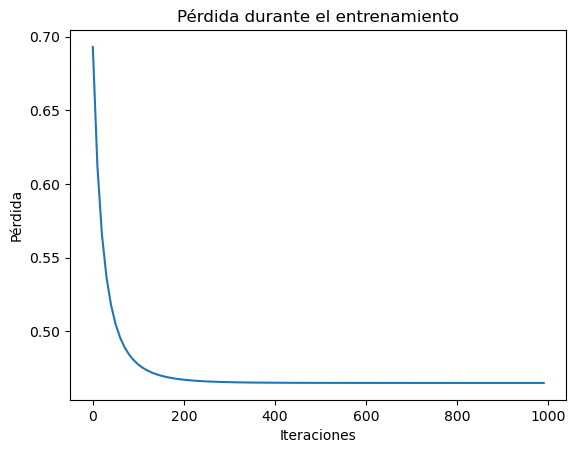

In [38]:
# Graficar la pérdida durante el entrenamiento
import matplotlib.pyplot as plt
plt.plot(range(0, model.n_iters, 10), model.losses)
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.title('Pérdida durante el entrenamiento')
plt.show()

## Referencias Bibliográficas y Lecturas Recomendadas

### 📖 Referencia Principal (La "Biblia" Moderna)

> **Murphy, K. P. (2022).** *Probabilistic Machine Learning: An Introduction*. MIT Press.
> Este texto es el estándar actual en programas de posgrado de IA. A diferencia de textos clásicos, unifica la visión probabilística (Bayesiana) con la optimización moderna (Gradient Descent), justificando exactamente las fórmulas utilizadas en este notebook.

### 📍 Mapeo de Secciones Específicas para este Proyecto

Para profundizar en la teoría detrás del código, se recomiendan las siguientes secciones del **Capítulo 10: Logistic Regression**:

* **Sección 10.2.1 - Model Specification (pág. 343):**
* **Relación con el código:** Define formalmente la función sigmoide  y explica por qué la distribución de salida es una **Bernoulli**: .
* **Dato clave:** Justifica el uso de la sigmoide como la función de "enlace canónico" para transformar el espacio lineal  al espacio de probabilidad .


* **Sección 10.2.3 - Maximum Likelihood Estimation (MLE) (pág. 346):**
* **Relación con el código:** Demuestra matemáticamente que minimizar la **Binary Cross-Entropy (Log-Loss)** es equivalente a maximizar la verosimilitud (MLE) de los datos bajo una distribución de Bernoulli.
* **Fórmula:** Muestra el paso de la verosimilitud  a la *Negative Log-Likelihood* (NLL), que es nuestra función `_compute_loss`.


* **Sección 10.2.4 - Gradient-based Optimization (pág. 347):**
* **Relación con el código:** Deriva el vector gradiente .
* **Validación:** Confirma que el gradiente tiene la forma elegante . Murphy explica que esta simplicidad ocurre porque la sigmoide coincide con la familia exponencial de la distribución de error.


* **Sección 10.3 - Regularized Logistic Regression (pág. 352):**
* **Relación con el código:** Explica la **Regularización L2 (Ridge)** no solo como una penalización geométrica, sino desde una perspectiva Bayesiana (MAP estimation) asumiendo una distribución previa Gaussiana sobre los pesos .
